# SVC - Noyau RBF
#### Pourquoi choisir ce model ?


Le SVC - Noyau RBF est adapté car :

- **capacité de séparation non-linéaire** : Contrairement à une régression classique qui cherche une ligne droite pour séparer les données, le SVC RBF projette les données dans un espace de dimension supérieure. C'est essentiel ici car un Pokémon légendaire n'est pas défini par une règle unique.

- **Dataset déséquillibré** : Le modèle cherche à maximiser l'espace entre les deux classes. C'est particulièrement utile sur un dataset déséquilibré (~12% de légendaires) car le modèle fait attention à bien positionner cette frontière pour ne pas "noyer" la classe minoritaire.

- **Prise en compte de plusieurs caractéristiques** : Le modèle répartit naturellement son analyse sur plusieurs caractéristiques à la fois. C'est intéressant après le Gradient Boosting qui s'appuyait à 70% sur une seule variable : le SVC-RBF nous donne un regard plus équilibré sur ce qui définit un légendaire.

## 1. Import et chargements des données

In [6]:
# importation des libraries
from Prepro import prepare_data
import pandas as pd
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

## 2. Recuperation des données

On separe les données du DataFrame en deux catégories :
- **X** : Toutes les colonnes (les statistiques)  qui servent à prédire
- **Y** : Ce qu'on veut prédire, c'est a dire estce que c'est un legendaire ?

Puis on les sépare en données d'entraînement et de test :
- **X_train / y_train** : Ce sont les données  d'entrainement
- **X_test / y_test** : Ce sont les données sur laquelle le modeles sera évalué

In [7]:
#chargement des données et préparation des données
df_clean = pd.read_csv("../../data/processed/pokemon_clean.csv")
X_train, X_test, y_train, y_test, preprocessor = prepare_data(df_clean)


## 3. Entrainement du modéle

In [8]:
# entraînement du modèle SVC avec kernel RBF
pipeline = make_pipeline(preprocessor,SVC(kernel='rbf', random_state=42))

#recherche des meilleurs hyperparamètres pour le modèle + validation croisée (cv=5)
param_grid = {'svc__C': [0.1, 1, 10, 100],'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1]}

grid = GridSearchCV(pipeline,param_grid,cv=5,scoring='f1',refit='f1',n_jobs=-1)# scoring='f1' : on évalue sur le F1 et pas l'accuracy car on a peu de légendaires
grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)

#prediction sur les données de test
y_pred = grid.predict(X_test)



Meilleurs paramètres : {'svc__C': 10, 'svc__gamma': 0.01}


La recherche par grille (GridSearch) est indispensable pour le SVC car ce modèle est très sensible à ses hyperparamètres.

Le paramètre `C` ajuste la "dureté" de la marge : une valeur optimale permet d'ignorer certains bruits (outliers) pour mieux capturer la tendance générale.

Le paramètre `Gamma` définit la zone d'influence d'un seul Pokémon : il détermine si la frontière doit être très ajustée aux données ou plus lisse.

## 4. Evaluation

### 4.1 Matrice de confusion

Matrice de confusion pour évaluer les performances du modèle en termes de vrais positifs, faux positifs, vrais négatifs et faux négatifs

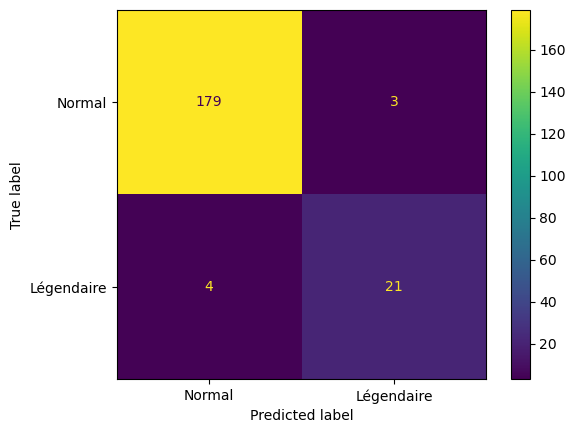

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Légendaire'])
disp.plot()

On observe qu'il y a :
- 179 : Pokémon normaux correctement identifiés
- 21 : Pokémon légendaires correctement identifiés 
- 3 : Un Pokémon normal classé à tort comme légendaire  (faux positif)
- 4 : Deux légendaires classés à tort comme normaux  (faux négatif)

### 4.2 Classification Report
Rapport de classification pour évaluer les performances du modèle en termes de précision, sensibilité et F1-score

In [10]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Légendaire']))

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       182
  Légendaire       0.88      0.84      0.86        25

    accuracy                           0.97       207
   macro avg       0.93      0.91      0.92       207
weighted avg       0.97      0.97      0.97       207



On observe que :
- Accuracy = 97%. Le modèle est globablement performant.
- Precision = 88% sur les légendaires : quand il dit "c'est un légendaire", il a raison 88% du temps
- Recall = 84% sur les légendaires : il retrouve 84% de tous les légendaires réels
- F1 = 86% sur les légendaires : bon équilibre entre les deux

## Conclusion
L'analyse des métriques révèle que le SVC-RBF est un modèle extrêmement robuste pour la discrimination des Pokémon légendaires. Avec une Accuracy globale de 97% et un F1-score de 0.86 sur la classe cible. Contrairement aux autres modèles, le SVC crée une frontière de décision courbe et continue, ce qui témoigne d'une compréhension plus globale et géométrique de ce qui définit un pokémon Légendaire.

Le modèle a correctement identifié 21 légendaires sur 25. Les 4 erreurs restantes sont des "Faux Négatifs" : le modèle a classé ces légendaires comme des Pokémon normaux.
Cela s'explique par la nature du SVC : c'est un modèle exigeant. Il ne classe un Pokémon en "Légendaire" que s'il possède une signature statistique très marquée et sans ambiguïté.

Pour ameliorer le model on pourrait essayer de : 
- Tester d'autres noyaux
- Supprimer les variables les moins corrélées à la classe "Légendaire" avant l'entraînement. Cela pourrait aider le noyau RBF à se concentrer sur les dimensions les plus discriminantes.
- Explorer des valeurs de `gamma` plus petites pour lisser davantage la frontière de décision